In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
transforms=transforms.ToTensor()
train_dataset=datasets.MNIST(root='./data',download=True,train=True,transform=transforms)
test_dataset=datasets.MNIST(root='./data',download=True,train=False,transform=transforms)


In [6]:
train_loader=DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=64,shuffle=True)


In [7]:
def add_noise(img,noise_factor=0.5):
    noisy=img+noise_factor*torch.randn_like(img)
    noisy=torch.clamp(noisy,0,1)
    return noisy

In [8]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder: 28 → 14 → 7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28 → 14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14 → 7
            nn.ReLU()
        )

        # Decoder: 7 → 14 → 28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # 7 → 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),    # 14 → 28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
model=Autoencoder().to(device)
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())



In [10]:
for epoch in range(5):
    running_loss=0
    for images,_ in train_loader:
        images=images.to(device)
        optimizer.zero_grad()
        output=model(images)
        loss=criterion(output,images)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()



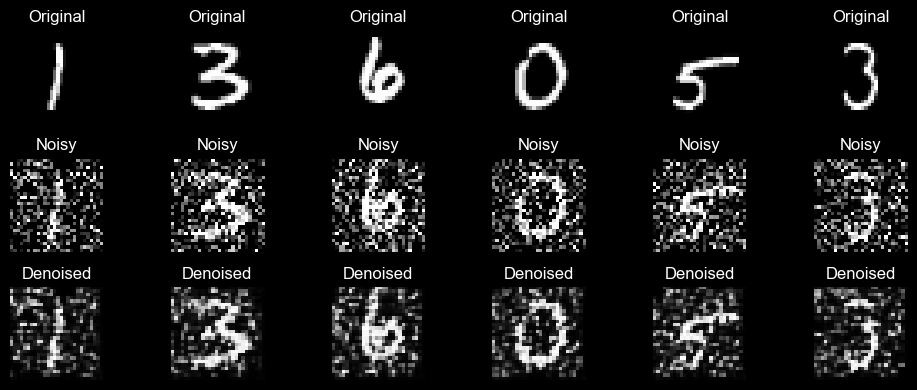

In [11]:
import matplotlib.pyplot as plt
model.eval()

dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.to(device)
noisy_images = add_noise(images)

with torch.no_grad():
    outputs = model(noisy_images)

# Move to CPU for plotting
images = images.cpu()
noisy_images = noisy_images.cpu()
outputs = outputs.cpu()

# Plot results
n = 6
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

